# Dataset 2
Cleaning and Overview

In [2]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [4]:

# Load datasets
df = pd.read_csv('../datasets/owid/womens-educational-attainment-vs-fertility.csv')


print("Head:")
print(df.head())
print("Shape:", df.shape)
print("Info:")
print(df.info())
print("Describe:")
print(df.describe())
print("Number of duplicates:", df.duplicated().sum())
if df.duplicated().any():
    df.drop_duplicates(inplace=True)
    print("Duplicates dropped. New shape:", df.shape)
print("Missing values per column:")
print(df.isnull().sum())

Head:
        Entity Code  Year  \
0  Afghanistan  AFG  1950   
1  Afghanistan  AFG  1951   
2  Afghanistan  AFG  1952   
3  Afghanistan  AFG  1953   
4  Afghanistan  AFG  1954   

   Fertility rate - Sex: all - Age: all - Variant: estimates  \
0                                              7.248           
1                                              7.260           
2                                              7.260           
3                                              7.266           
4                                              7.254           

   Combined - average years of education for 15-64 years female youth and adults  \
0                                               0.08                               
1                                                NaN                               
2                                                NaN                               
3                                                NaN                               
4             

In [6]:
# Filter only years from 1950 to 2020
df = df[(df['Year'] >= 1950) & (df['Year'] <= 2020)]
# print the shape after filtering
print("Shape after filtering years 1950-2020:", df.shape)

Shape after filtering years 1950-2020: (18943, 7)


In [22]:
# Convert GDP and Population values to numeric

def convert_to_numeric(val):
    if isinstance(val, str):
        val = val.replace('k', 'e3').replace('M', 'e6')
        try:
            return float(val)
        except ValueError:
            return np.nan
    return val

gdp_filtered = gdp_filtered.apply(np.vectorize(convert_to_numeric))
population_filtered = population_filtered.apply(np.vectorize(convert_to_numeric))

# Sjow the first few rows and the shapes of the converted datasets
print("Converted GDP values:")
print(gdp_filtered.head())
print("Converted Population values:")
print(population_filtered.head())
print("gdp_filtered shape after conversion:", gdp_filtered.shape)
print("population_filtered shape after conversion:", population_filtered.shape)



Converted GDP values:
                1970     1971     1972     1973     1974     1975     1976  \
country                                                                      
Afghanistan   1980.0   1950.0   1600.0   1630.0   1690.0   1760.0   1830.0   
Angola        5090.0   5180.0   5160.0   5460.0   5400.0   4160.0   3830.0   
Albania       3980.0   4110.0   4240.0   4390.0   4440.0   4500.0   4560.0   
Andorra      43300.0  43300.0  44700.0  46100.0  46800.0  45400.0  45600.0   
UAE          84900.0  86000.0  86100.0  86400.0  92800.0  85000.0  86200.0   

                1977     1978     1979  ...     2006     2007     2008  \
country                                 ...                              
Afghanistan   1710.0   1810.0   1750.0  ...   1360.0   1530.0   1560.0   
Angola        3840.0   3770.0   3780.0  ...   6590.0   7310.0   7860.0   
Albania       4620.0   4690.0   4760.0  ...   8560.0   9140.0   9910.0   
Andorra      45700.0  45200.0  44000.0  ...  65200.0  66500.0

In [23]:
# Save filtered datasets
fertility_filtered.to_csv('../datasets/gapminder/children_per_woman_total_fertility_filtered.csv')
gdp_filtered.to_csv('../datasets/gapminder/gdp_pcap_filtered.csv')
population_filtered.to_csv('../datasets/gapminder/pop_filtered.csv')
gender_school_filtered.to_csv('../datasets/gapminder/mean_years_in_school_woman_percent_men_25_to_34_years_filtered.csv')


Min GDP: 390.0
Max GDP: 150000.0
Mean GDP: 13375.578190743337


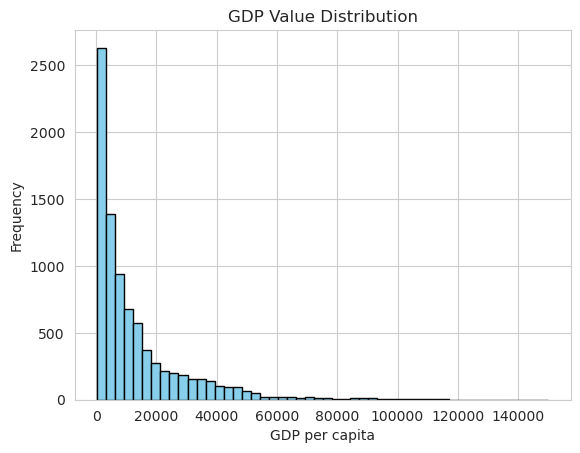

In [24]:
# Flatten the DataFrame to a 1D array, drop NaNs
gdp_values = gdp_filtered.values.flatten()
gdp_values = gdp_values[~np.isnan(gdp_values)]

# Print min, max, mean
print("Min GDP:", np.min(gdp_values))
print("Max GDP:", np.max(gdp_values))
print("Mean GDP:", np.mean(gdp_values))

# Plot value distribution
plt.hist(gdp_values, bins=50, color='skyblue', edgecolor='black')
plt.title("GDP Value Distribution")
plt.xlabel("GDP per capita")
plt.ylabel("Frequency")
plt.show()

Choosing a linear scale for GDP is not appropriate due to the wide range of values. A logarithmic scale is more suitable for visualizing GDP data, as it compresses the scale and allows for better comparison across countries with vastly different GDPs.